# 8.2.2 牛顿方向与非凸曲率

## 学习目标与先修知识

从二阶近似推导牛顿方向，用反例判断方向是否下降。

先修：8.1的二阶展开、8.2.1的梯度（gradient）下降，线性方程求解。 [本篇学习次序](../README.md)。

## 具体问题

梯度只看当前坡度。若同时利用曲率，能否跨过狭长谷底？牛顿方向常能更快，但在双井中也可能指向上坡；先把“方向正确”和“步长合适”拆开研究。

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
point=.2;gradient=point**3-point;curvature=3*point**2-1
raw=-gradient/curvature
print('原牛顿方向',raw,'方向导数',gradient*raw,'（正数表示局部上升）')

原牛顿方向 -0.2181818181818182 方向导数 0.0418909090909091 （正数表示局部上升）


## 模型假设

二次目标部分使用正定（positive definite）H；非凸部分使用无量纲（dimensionless）双井f=x⁴/4−x²/2。线性方程直接求解，不显式求逆。在非驻点（stationary point）处，选出的方向使目标局部下降；沿该方向走多远合适，则需要下一节的回溯来决定。

## 数学解释与推导

### 最小化局部二次近似

固定当前点，把移动量p当作变量：
$$m(p)=f(x)+g^Tp+\frac12p^THp.$$
若H正定，令 $\nabla_p m=g+Hp=0$，得到牛顿方程 $Hp=-g$。于是
$$g^Tp=-p^THp<0\quad(g\ne0).$$
对严格凸二次函数，局部近似就是原函数，$x+p=H^{-1}b$ 一步到解。一般非线性函数还含高阶项，全步可能太远。

### 非凸时不能机械套方程

双井在x=.2处有 $g=-.192,h=-.88$，原牛顿方向 $p=-g/h\approx-.2182$，方向导数（derivative）为正。H可逆仅说明方程可解，不说明局部模型（model）存在最小值。

本节的标量保护规则是：若g=0，报告驻点；若h>0取−g/h；否则改取−g。多维情形可通过修改 H 或使用信赖域构造下降方向。

### 快收敛有明确前提

在非退化最小点附近、H正定且变化足够平滑（例如H局部Lipschitz连续）时，精确牛顿全步可有二次局部收敛：足够近时误差满足 $\|e_{k+1}\|\le C\|e_k\|^2$。它不是任意初值（initial condition）的全局保证。梯度为零也只说明一阶驻点，双井的x=0仍是局部最大。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]


def solve_linear(matrix, right):
    """Partial-pivot elimination for the tiny classroom systems."""
    rows = [list(map(float, row))+[float(value)] for row, value in zip(matrix, right)]
    size = len(rows)
    for column in range(size):
        pivot = max(range(column, size), key=lambda i: abs(rows[i][column]))
        if abs(rows[pivot][column]) < 1e-12:
            return None
        rows[column], rows[pivot] = rows[pivot], rows[column]
        scale = rows[column][column]
        rows[column] = [value/scale for value in rows[column]]
        for i in range(size):
            if i != column:
                factor = rows[i][column]
                rows[i] = [a-factor*b for a, b in zip(rows[i], rows[column])]
    return [row[-1] for row in rows]


def quartic_direction(point):
    gradient = point**3-point
    curvature = 3*point**2-1
    if gradient == 0:
        return 0., 'stationary'
    if curvature > 0:
        return -gradient/curvature, 'newton'
    return -gradient, 'gradient_fallback'

## 对照实验

x 0.2 保护方向 0.192 类型 gradient_fallback
x 1.3 保护方向 -0.2203931203931204 类型 newton


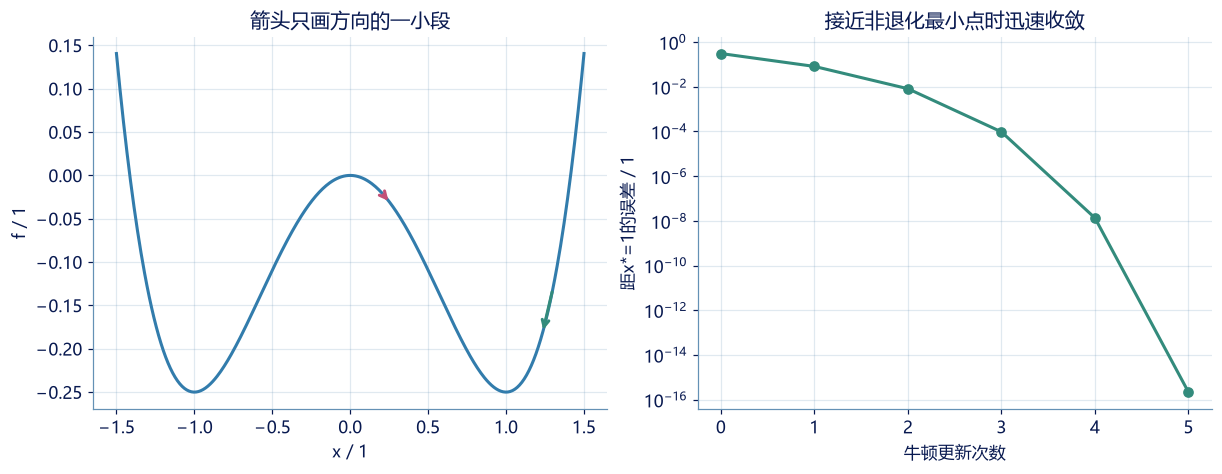

In [4]:
grid=np.linspace(-1.5,1.5,400);f=lambda x:x**4/4-x*x/2
fig,axes=plt.subplots(1,2,figsize=(11,4.2))
axes[0].plot(grid,f(grid),color=BLUE)
for x,color in [(.2,PINK),(1.3,GREEN)]:
    p,kind=quartic_direction(x)
    axes[0].annotate('',xy=(x+.3*p,f(x+.3*p)),xytext=(x,f(x)),arrowprops=dict(arrowstyle='->',color=color,lw=2))
    print('x',x,'保护方向',p,'类型',kind)
axes[0].set(xlabel='x / 1',ylabel='f / 1',title='箭头只画方向的一小段')
history=[1.3]
for _ in range(5):
    x=history[-1];history.append(x-(x**3-x)/(3*x*x-1))
error=np.abs(np.array(history)-1)
axes[1].semilogy(np.maximum(error,1e-16),'o-',color=GREEN)
axes[1].set(xlabel='牛顿更新次数',ylabel='距x*=1的误差 / 1',title='接近非退化最小点时迅速收敛');plt.show()

### 独立核验与边界

In [5]:
H=np.array([[2.,1.],[1.,4.]]);b=np.array([2.,-1.]);x=np.array([3.,2.])
p=np.array(solve_linear(H,-np.array(quadratic(H,b,x)[1])))
np.testing.assert_allclose(x+p,np.linalg.solve(H,b),atol=1e-12)
for point in [-1.5,-.5,.2,1.5]:
    direction,_=quartic_direction(point)
    assert (point**3-point)*direction<0
assert quartic_direction(0)==(0.,'stationary')
print('二次一步解、方向符号及非最小驻点检查通过。')

二次一步解、方向符号及非最小驻点检查通过。


## 结果解释

非凸反例里负曲率会把原始牛顿步变成上坡，保护方向才恢复局部下降。右图从 1.3 出发接近 x=1，展示这段局部轨迹（trajectory）的收敛速度。下一节继续检查，沿下降方向实际走多远。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：检查牛顿方向是否下降

对f(x)=x⁴/4−x²/2，根据当前曲率选择方向。

**函数与代码模板**

```python
def solve(
    point: float,
) -> tuple[float, str]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `point` | `float` | 当前标量坐标x。 | 无量纲 |

**返回值**

按以下顺序返回元组：(direction, kind)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `direction` | `float` | 选出的搜索方向p。 | 无量纲 |
| `kind` | `str` | stationary、newton或gradient_fallback。 | 不适用 |

**计算规则**

g=x³−x，h=3x²−1。g=0返回(0,stationary)；否则h>0取−g/h并标newton，h≤0改取−g并标gradient_fallback。

**约束与边界**

- −3≤point≤3；比较按给定浮点数直接计算；stationary不等于最小。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| point | 当前标量坐标x。 | 0.2 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
point = 0.2

result = solve(point)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| direction | 选出的搜索方向p。 | 0.192 | 无量纲 |
| kind | stationary、newton或gradient_fallback。 | gradient_fallback | 不适用 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.192, 'gradient_fallback')
```

**样例解释**

x=.2时g=−.192，h=−.88；原始牛顿方向会向上，改用−g=.192。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：检查牛顿方向是否下降](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-newton-direction)

### 第 2 题 · 多项选择题：牛顿步从哪里来

局部模型（model）m(p)=f(x)+gᵀp+pᵀHp/2，H正定（positive definite）。哪些陈述正确？

- **A.** 最小化m给出Hp=−g。
- **B.** 可以把Hp=−g直接当作原非凸函数的全局最小。
- **C.** g非零时gᵀp=−pᵀHp<0。
- **D.** 二次目标用精确牛顿全步可一步到唯一解。

[作答：牛顿步从哪里来](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-newton-taylor)

### 第 3 题 · 单项选择题：回溯不能修好错误方向

在f(x)=x⁴/4−x²/2的x=.2处，原始牛顿方向与梯度（gradient）同号。应怎样处理？

- **A.** 一直减小正步长，必定获得一阶下降。
- **B.** 先检查g·p；不是下降方向时换用−g。
- **C.** 只要能解出牛顿方程就接受全步。
- **D.** 宣称函数无最小值。

[作答：回溯不能修好错误方向](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-negative-curvature)

### 第 4 题 · 多项选择题：停在零处应如何报告

保护牛顿算法从x=0出发，梯度（gradient）检查立即停止。哪些表述诚实？

- **A.** 一阶驻点（stationary point）条件满足。
- **B.** 已经证得全局最小。
- **C.** 还需看曲率，当前h=−1。
- **D.** 这一结果说明停止条件本身不能排除极大点。

[作答：停在零处应如何报告](http://127.0.0.1:8000/chapters/08-02-%E6%A2%AF%E5%BA%A6%E3%80%81%E6%9B%B2%E7%8E%87%E4%B8%8E%E8%BF%AD%E4%BB%A3%E7%AE%97%E6%B3%95/practice/?question=p08-stationary-stop)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第9章：牛顿方向、局部收敛及阻尼步。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-02-梯度、曲率与迭代算法/explore/) · [本篇目录](../README.md)